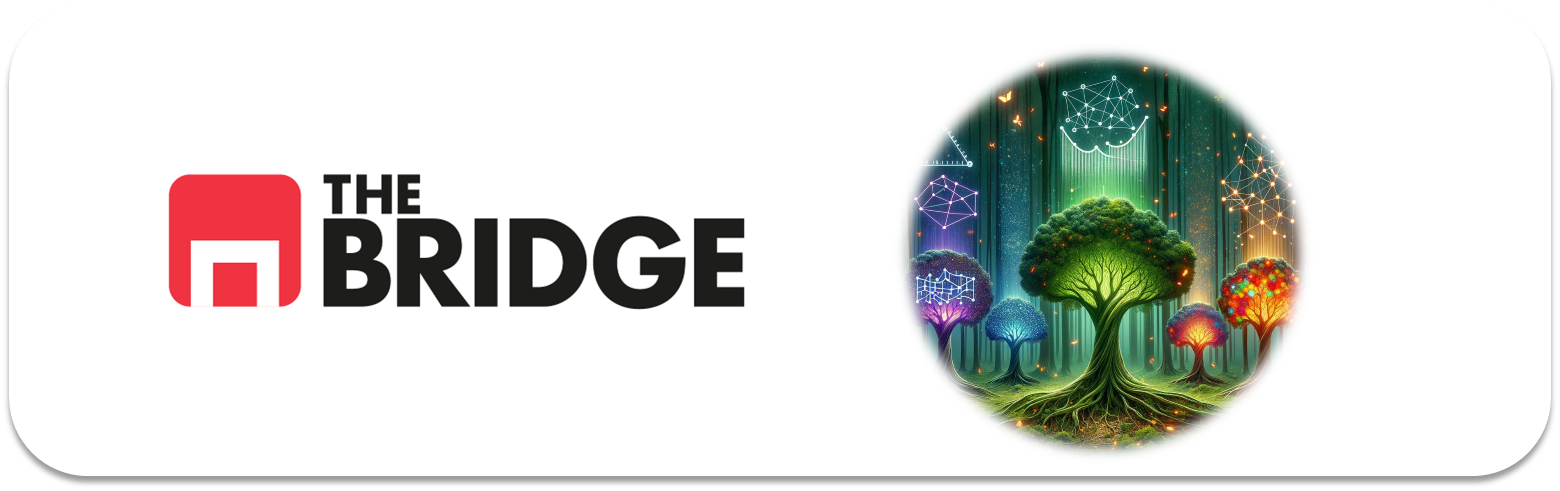

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
)

from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_combined_graphs,
    plot_categorical_relationship,
    plot_categorical_numerical_relationship,
)

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

### Paso 1 — Carga y exploración inicial

In [2]:
df = pd.read_csv("data/bank-full.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Paso 2 — Target: identificación y distribución

La variable objetivo es **`y`**: indica si el cliente contrató el depósito a plazo ("yes") o no ("no").
Es obligatorio analizar su distribución — hay un claro **desbalanceo de clases** que condicionará todo el proceso.

In [5]:
print(df["y"].value_counts())
print()
print(df["y"].value_counts(normalize=True).round(3))

y
no     39922
yes     5289
Name: count, dtype: int64

y
no     0.883
yes    0.117
Name: proportion, dtype: float64


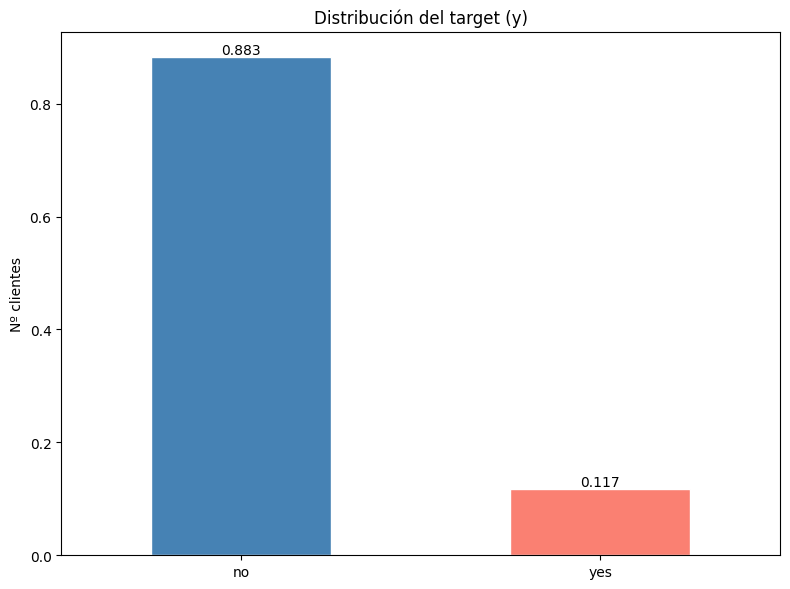

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
conteos = df["y"].value_counts(normalize=True).round(3)
conteos.plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="white")
ax.set_title("Distribución del target (y)")
ax.set_xlabel("")
ax.set_ylabel("Nº clientes")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", xytext=(0, 0), textcoords="offset points",
    )
plt.tight_layout()
plt.show()

### Paso 3 — Mini EDA

Exploración rápida de la distribución de variables numéricas y categóricas,
y su relación con el target.

Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


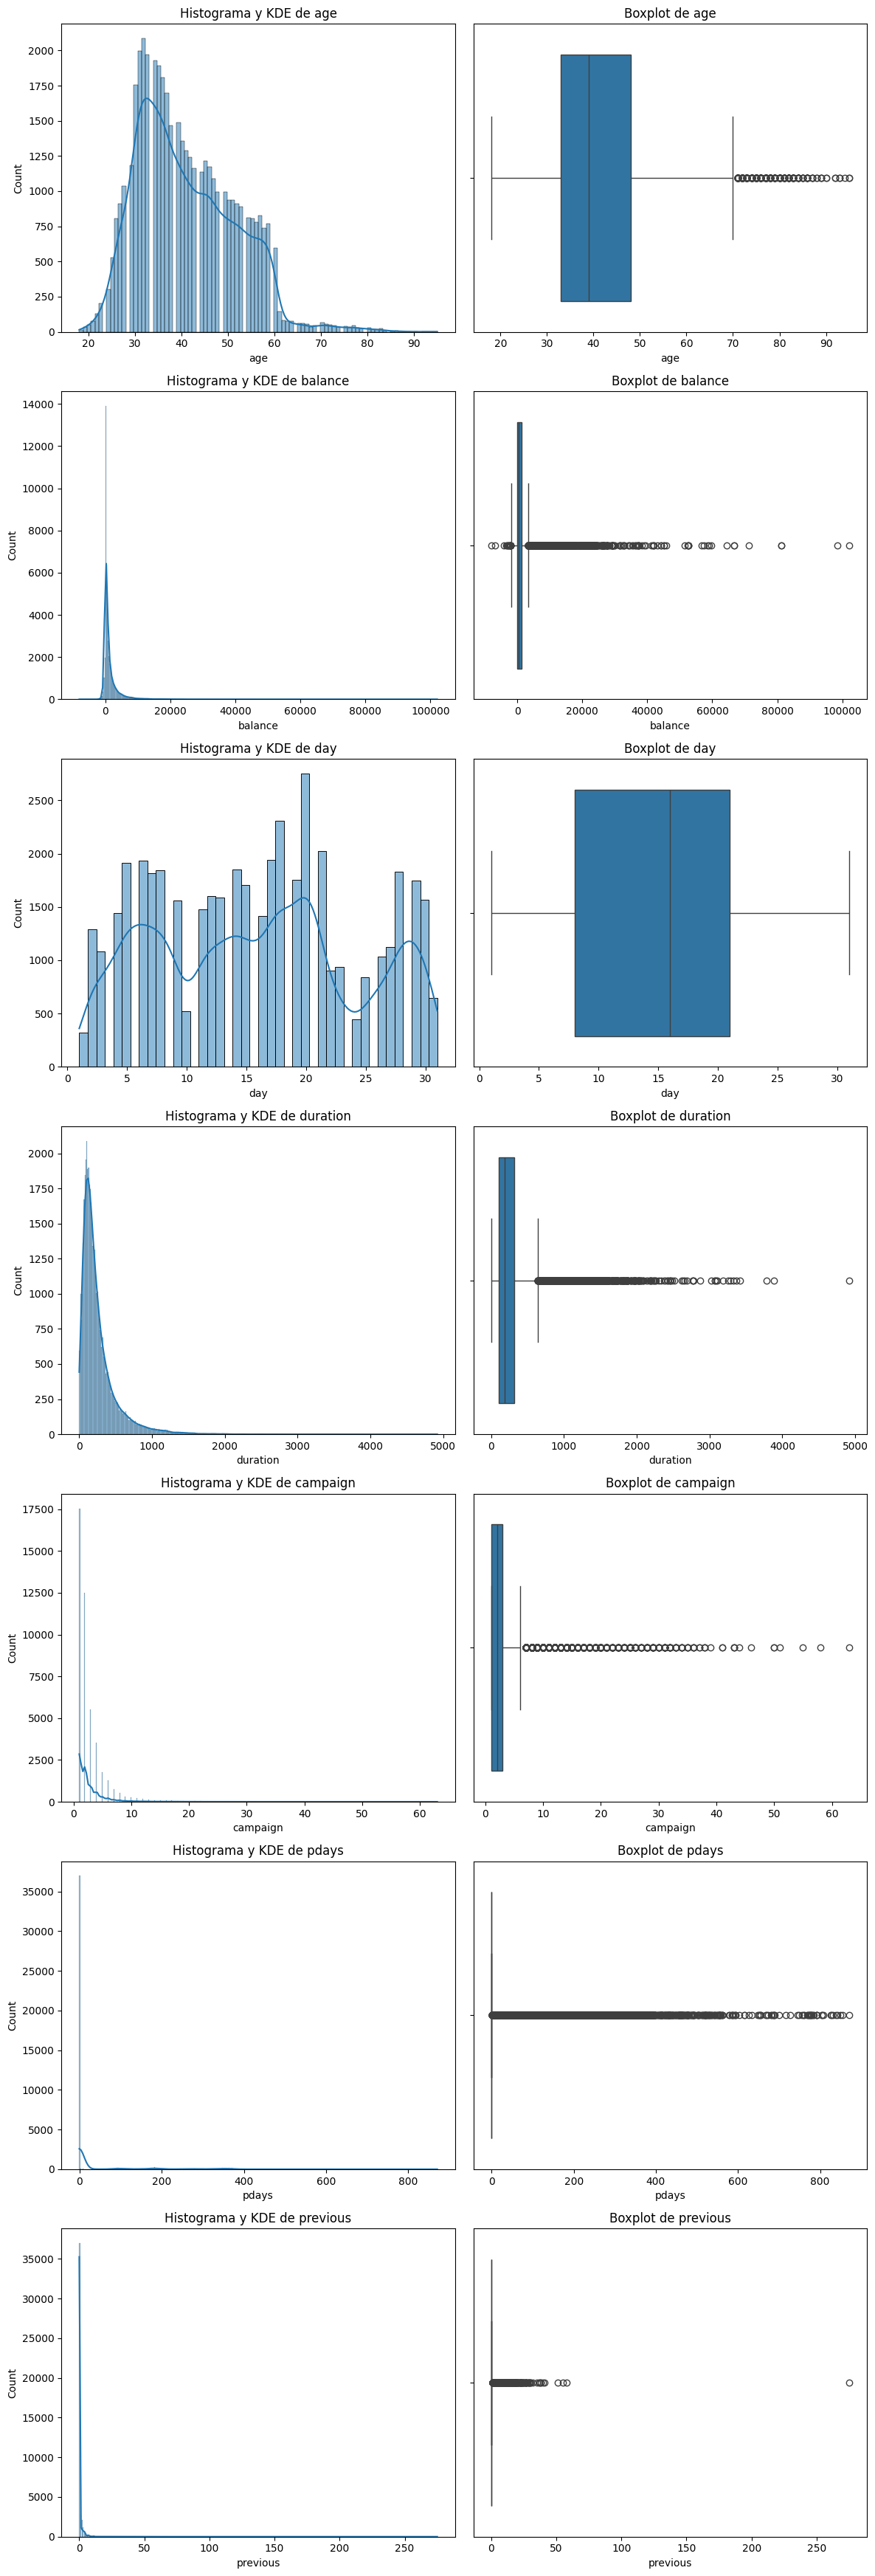

In [7]:
# Variables numéricas: histograma + KDE + boxplot
cols_num = df.select_dtypes(include="number").columns.tolist()
print("Variables numéricas:", cols_num)
plot_combined_graphs(df, cols_num)

C:\Users\pc\AppData\Local\Temp\ipykernel_13736\3765579717.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df.select_dtypes(include="object").columns.drop("y").tolist()


Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


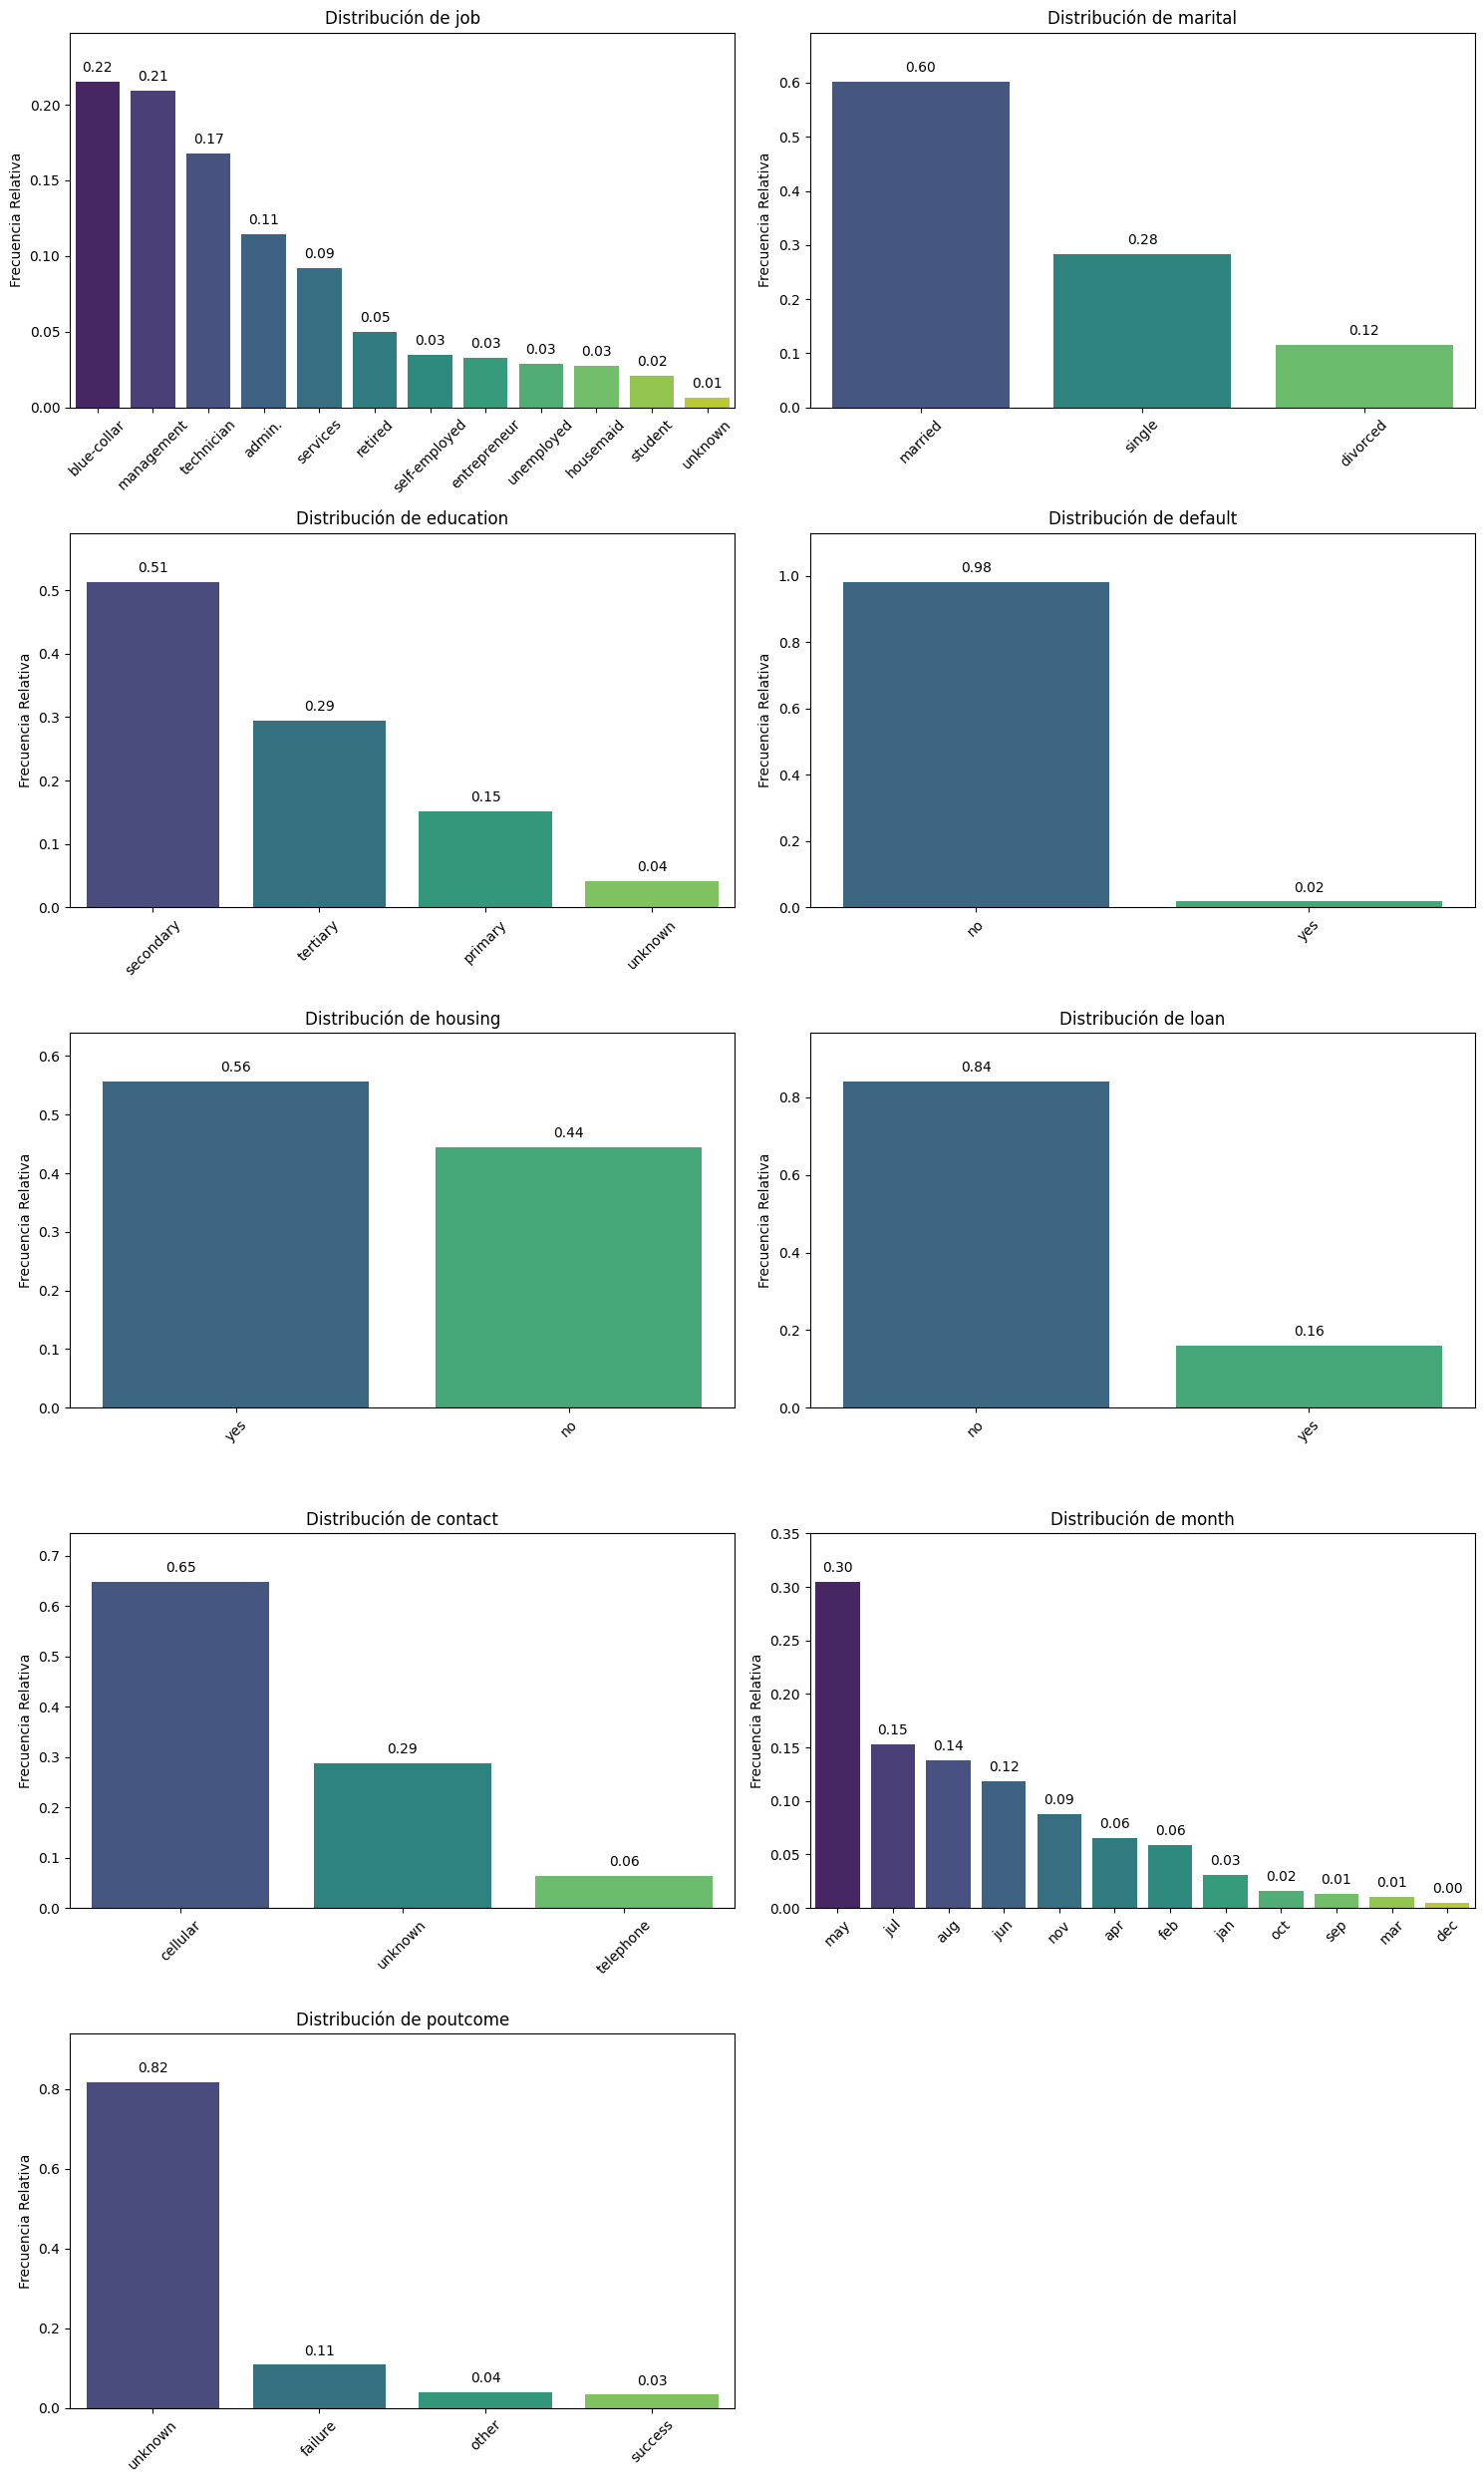

In [8]:
# Variables categóricas (excepto target): distribución relativa
cols_cat = df.select_dtypes(include="object").columns.drop("y").tolist()
print("Variables categóricas:", cols_cat)
pinta_distribucion_categoricas(df, cols_cat, relativa=True, mostrar_valores=True)

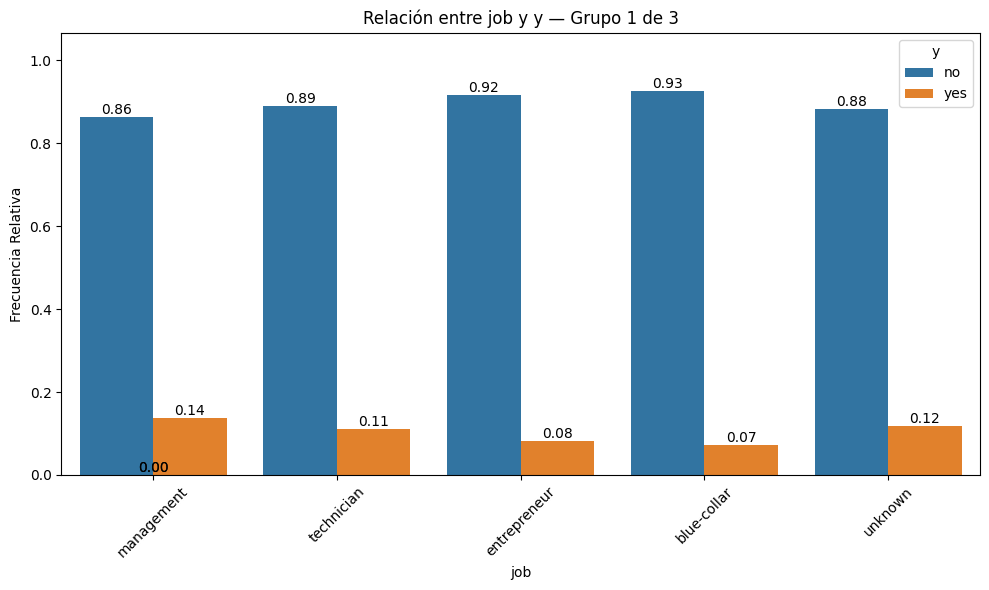

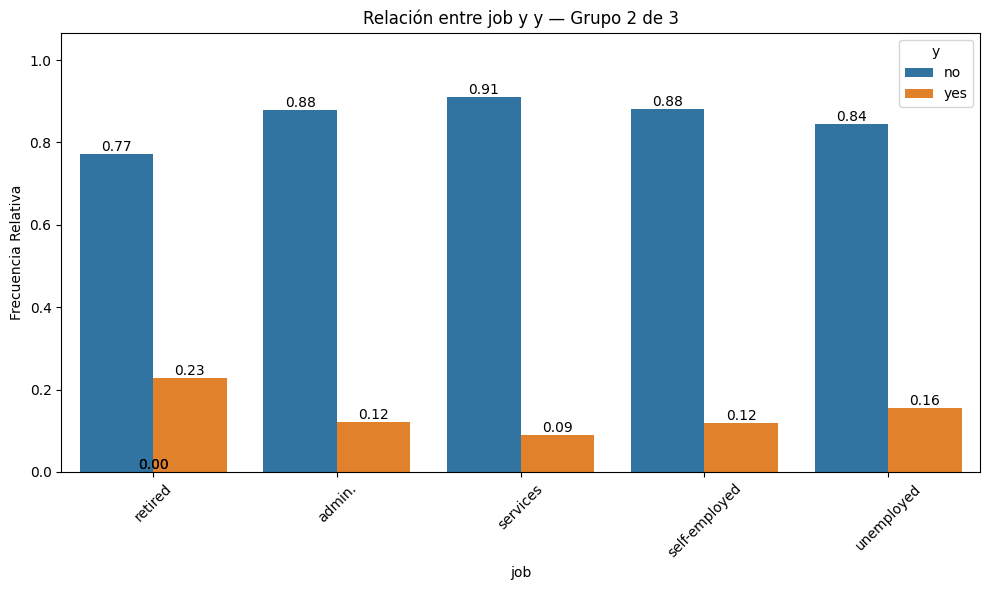

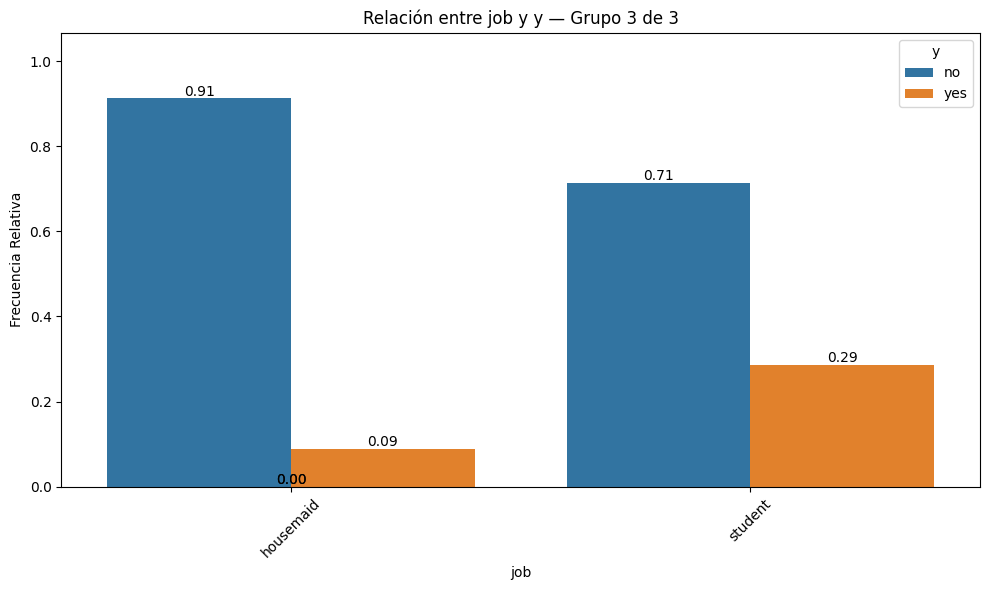

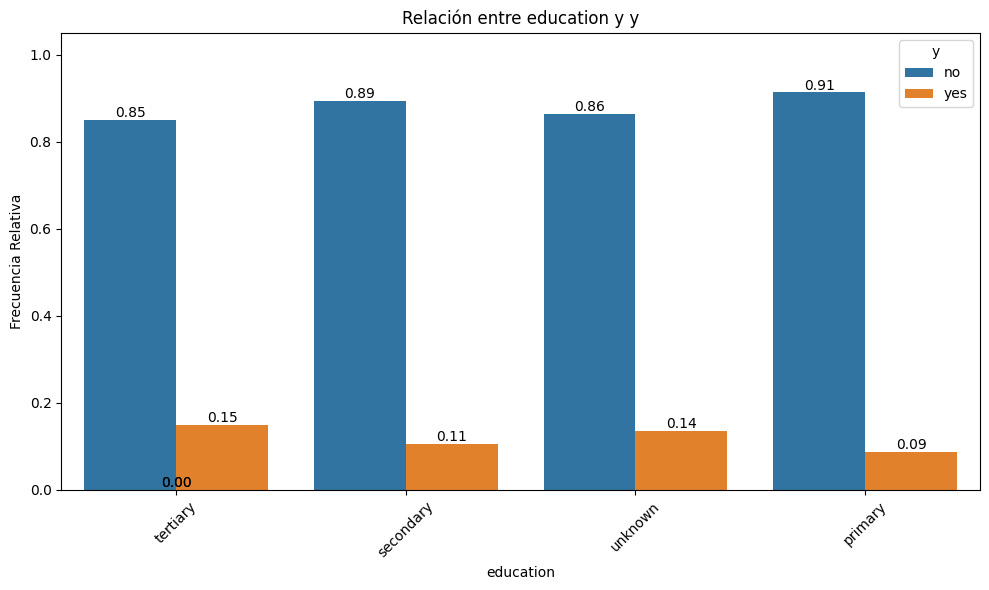

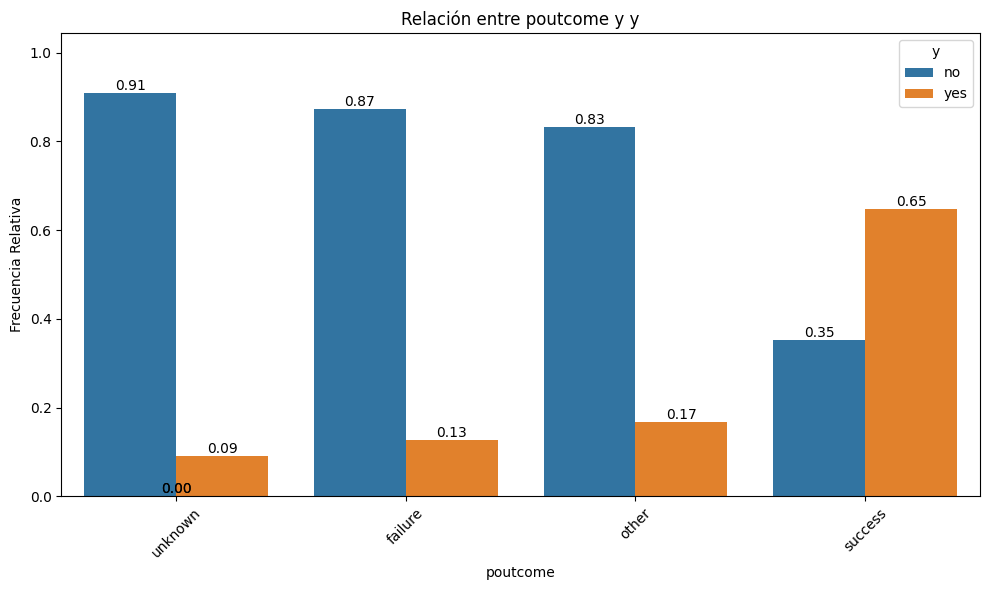

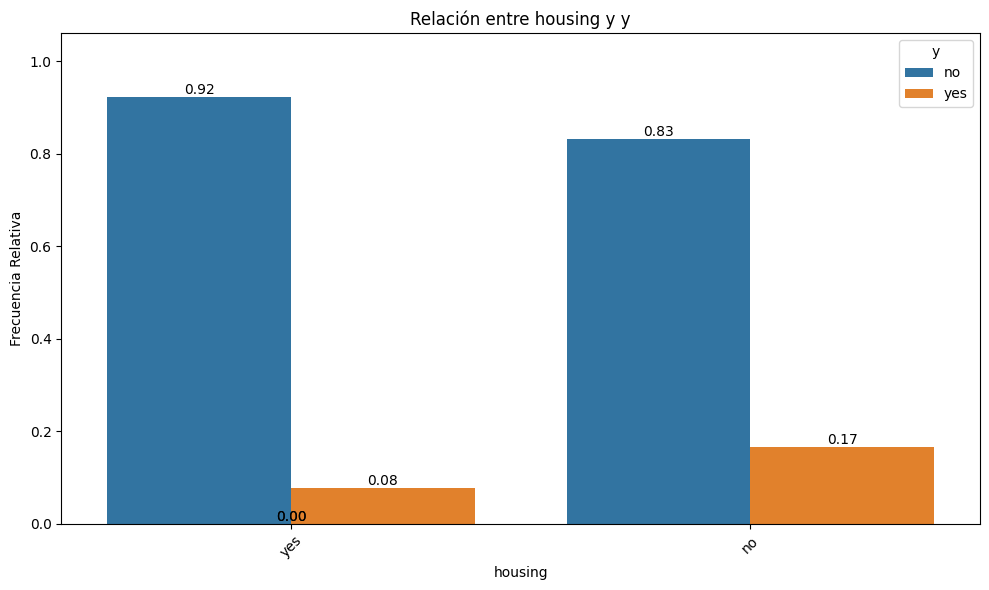

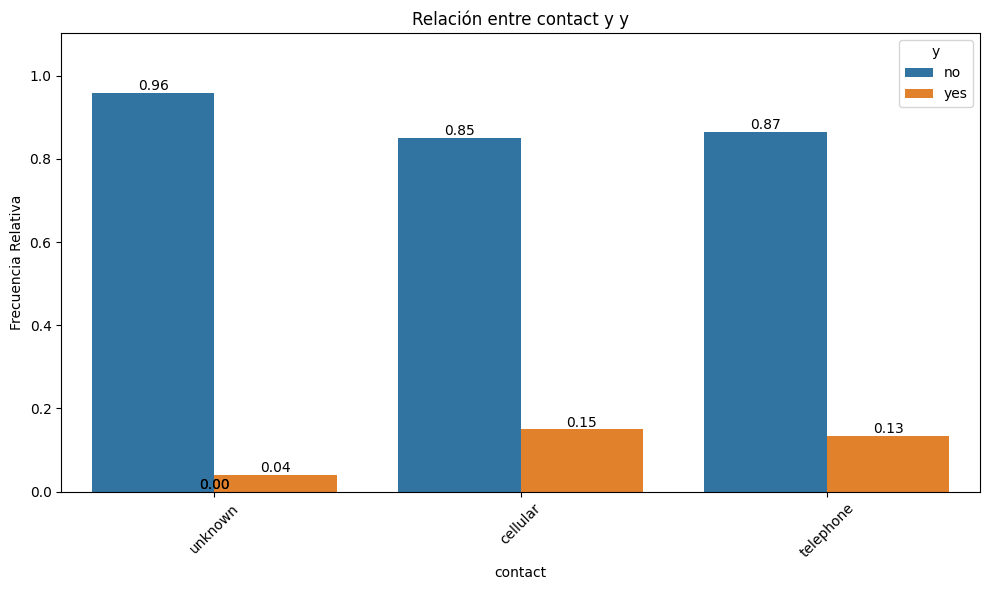

In [9]:
# Relación de las variables más relevantes con el target
for col in ["job", "education", "poutcome", "housing", "contact"]:
    plot_categorical_relationship(df, col, "y", relative_freq=True, show_values=True)

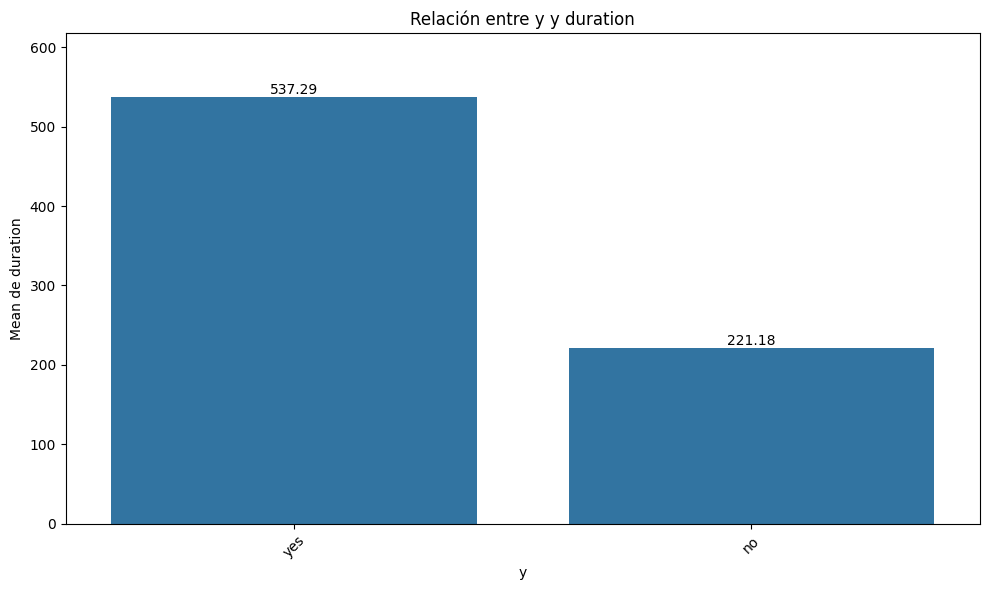

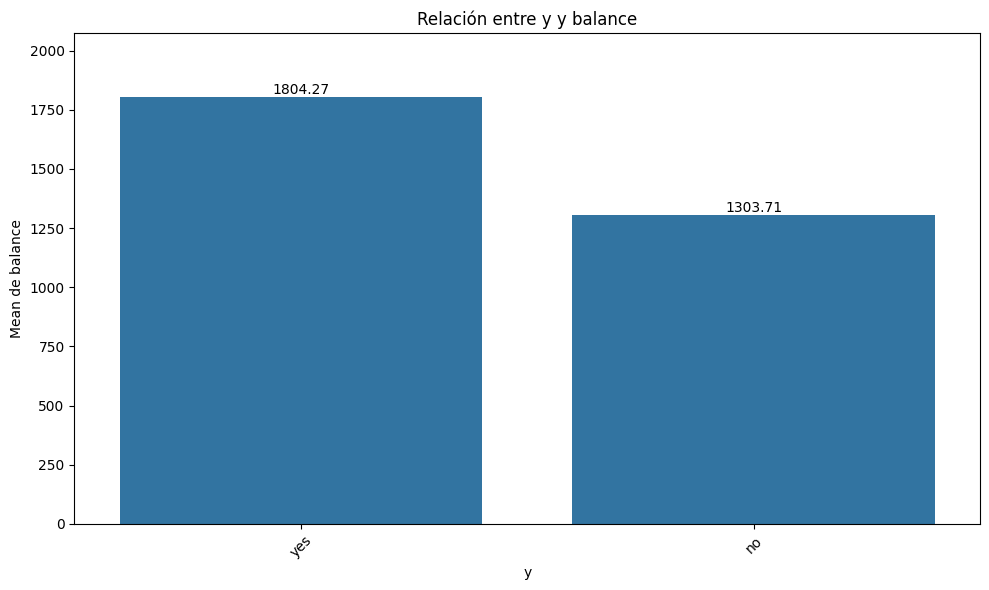

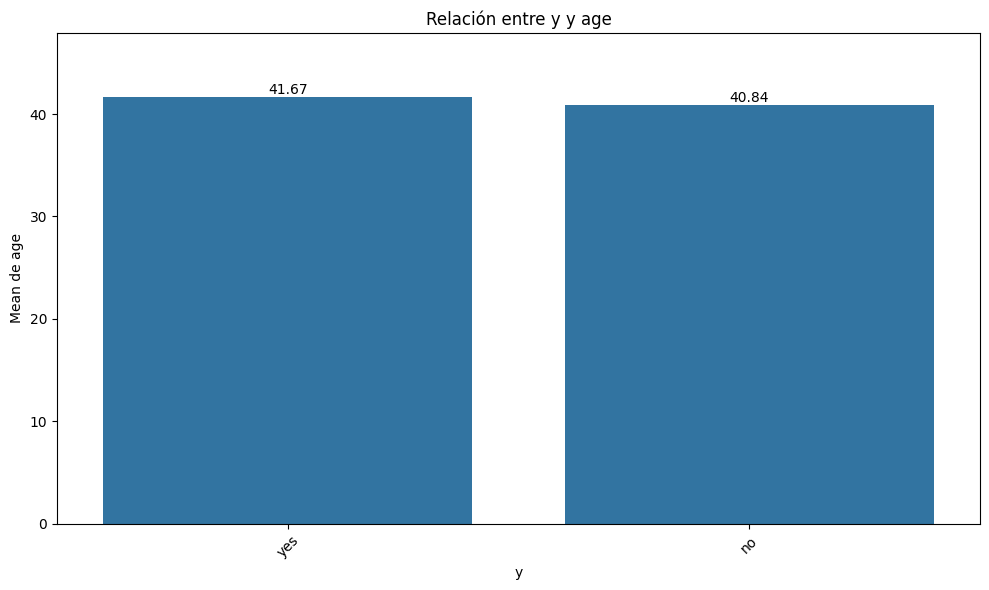

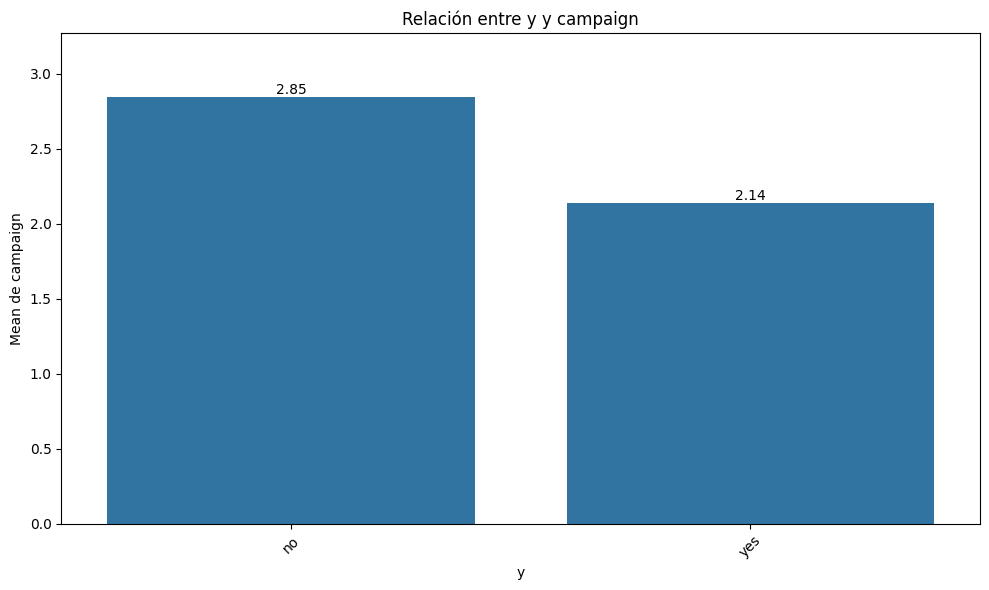

In [10]:
# Media de las variables numéricas clave agrupada por target
for col in ["duration", "balance", "age", "campaign"]:
    plot_categorical_numerical_relationship(df, "y", col, show_values=True)

### Paso 4 — Preprocesamiento

El dataset no tiene nulos, pero tiene variables categóricas (incluyendo "unknown" como categoría válida).
Aplicamos `LabelEncoder` a todas las columnas de tipo objeto, incluido el target.

In [11]:
df_enc = df.copy()
le = LabelEncoder()

for col in df_enc.select_dtypes(include="object").columns:
    df_enc[col] = le.fit_transform(df_enc[col])

print("Encoding completado.")
print(df_enc.dtypes)
df_enc.head()

Encoding completado.
age          int64
job          int64
marital      int64
education    int64
default      int64
balance      int64
housing      int64
loan         int64
contact      int64
day          int64
month        int64
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome     int64
y            int64
dtype: object


C:\Users\pc\AppData\Local\Temp\ipykernel_13736\3751237581.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_enc.select_dtypes(include="object").columns:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


### Paso 5 — Split train / test

Usamos `stratify=y` para mantener la proporción de clases en ambos conjuntos,
lo que es fundamental dado el desbalanceo (~88% no / ~12% yes).

In [12]:
X = df_enc.drop(columns="y")
y = df_enc["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} muestras")
print(f"Test:  {X_test.shape[0]:,} muestras")
print(f"\nDistribución del target en train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribución del target en test:\n{y_test.value_counts(normalize=True).round(3)}")

Train: 36,168 muestras
Test:  9,043 muestras

Distribución del target en train:
y
0    0.883
1    0.117
Name: proportion, dtype: float64

Distribución del target en test:
y
0    0.883
1    0.117
Name: proportion, dtype: float64


### Paso 6 — Modelo baseline: Regresión Logística

Entrenamos una regresión logística **sin optimizar** (hiperparámetros por defecto) como referencia.
Usamos `class_weight="balanced"` para compensar el desbalanceo.

=== REGRESIÓN LOGÍSTICA (baseline) ===
              precision    recall  f1-score   support

          no       0.97      0.80      0.87      7985
         yes       0.35      0.82      0.49      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.68      9043
weighted avg       0.90      0.80      0.83      9043

ROC-AUC: 0.8720


c:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


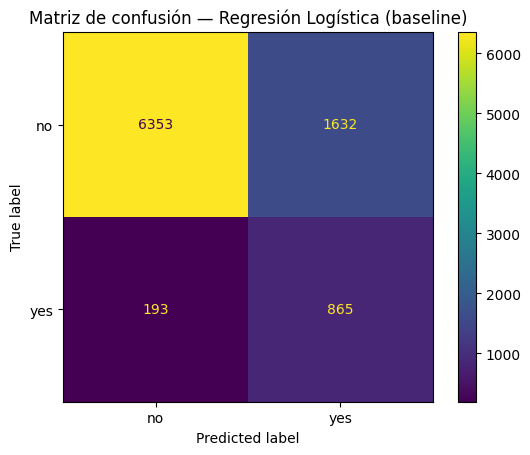

In [13]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
roc_lr     = roc_auc_score(y_test, y_proba_lr)

print("=== REGRESIÓN LOGÍSTICA (baseline) ===")
print(classification_report(y_test, y_pred_lr, target_names=["no", "yes"]))
print(f"ROC-AUC: {roc_lr:.4f}")

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, display_labels=["no", "yes"])
plt.title("Matriz de confusión — Regresión Logística (baseline)")
plt.show()

#### (EXTRA) Validación cruzada del baseline

Entrenar la regresión logística sobre `X_train` y evaluarla sobre `X_test` da un único número de ROC-AUC sobre una única partición. El problema es que `GridSearchCV` reporta su `best_score_` como el promedio de 5 folds sobre `X_train`, así que comparar esos dos números directamente no es del todo justo: uno tiene varianza de un solo split y el otro es un promedio.

Para igualar el terreno aplicamos `cross_val_score` con los mismos 5 folds y la misma métrica (`roc_auc`) sobre el baseline. Esto nos da la media y la desviación típica del ROC-AUC de la regresión logística estimados de forma equivalente a como GridSearchCV evalúa el árbol. Si la media de CV está cerca del score en test, confirma que el split único era representativo y que el modelo generaliza de forma estable. La desviación típica indica cuánto varía el rendimiento según qué datos caen en cada fold — valores bajos (&lt;0.01) con 36.000 muestras de train son normales y esperables.

In [14]:
scores_lr = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    X_train, y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

print("=== REGRESIÓN LOGÍSTICA — Validación cruzada (5 folds) ===")
print(f"ROC-AUC por fold: {scores_lr.round(4)}")
print(f"Media:            {scores_lr.mean():.4f}")
print(f"Desviación típica:{scores_lr.std():.4f}")
print()
print(f"ROC-AUC en test (split único): {roc_lr:.4f}")
print(f"Árbol optimizado  CV (5 folds): {gs.best_score_:.4f}  ← comparable con la media de arriba")

=== REGRESIÓN LOGÍSTICA — Validación cruzada (5 folds) ===
ROC-AUC por fold: [0.8696 0.8622 0.8674 0.871  0.876 ]
Media:            0.8692
Desviación típica:0.0045

ROC-AUC en test (split único): 0.8720


NameError: name 'gs' is not defined

### Paso 7 — Árbol de Decisión: primer entrenamiento (sin optimizar)

Entrenamos un árbol con todos los parámetros por defecto para ver su comportamiento
antes de ajustar hiperparámetros. Se espera sobreajuste (árbol muy profundo).

=== ÁRBOL DE DECISIÓN (sin optimizar) ===
Profundidad del árbol: 38
              precision    recall  f1-score   support

          no       0.92      0.94      0.93      7985
         yes       0.47      0.42      0.44      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.68      0.69      9043
weighted avg       0.87      0.88      0.87      9043

ROC-AUC: 0.6801


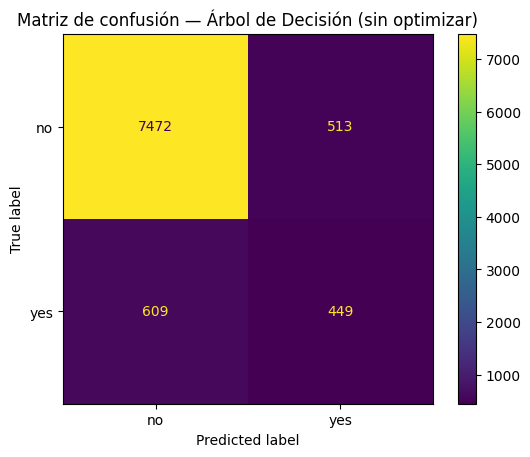

In [ ]:
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)

y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]
roc_dt     = roc_auc_score(y_test, y_proba_dt)

print("=== ÁRBOL DE DECISIÓN (sin optimizar) ===")
print(f"Profundidad del árbol: {dt.get_depth()}")
print(classification_report(y_test, y_pred_dt, target_names=["no", "yes"]))
print(f"ROC-AUC: {roc_dt:.4f}")

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, display_labels=["no", "yes"])
plt.title("Matriz de confusión — Árbol de Decisión (sin optimizar)")
plt.show()

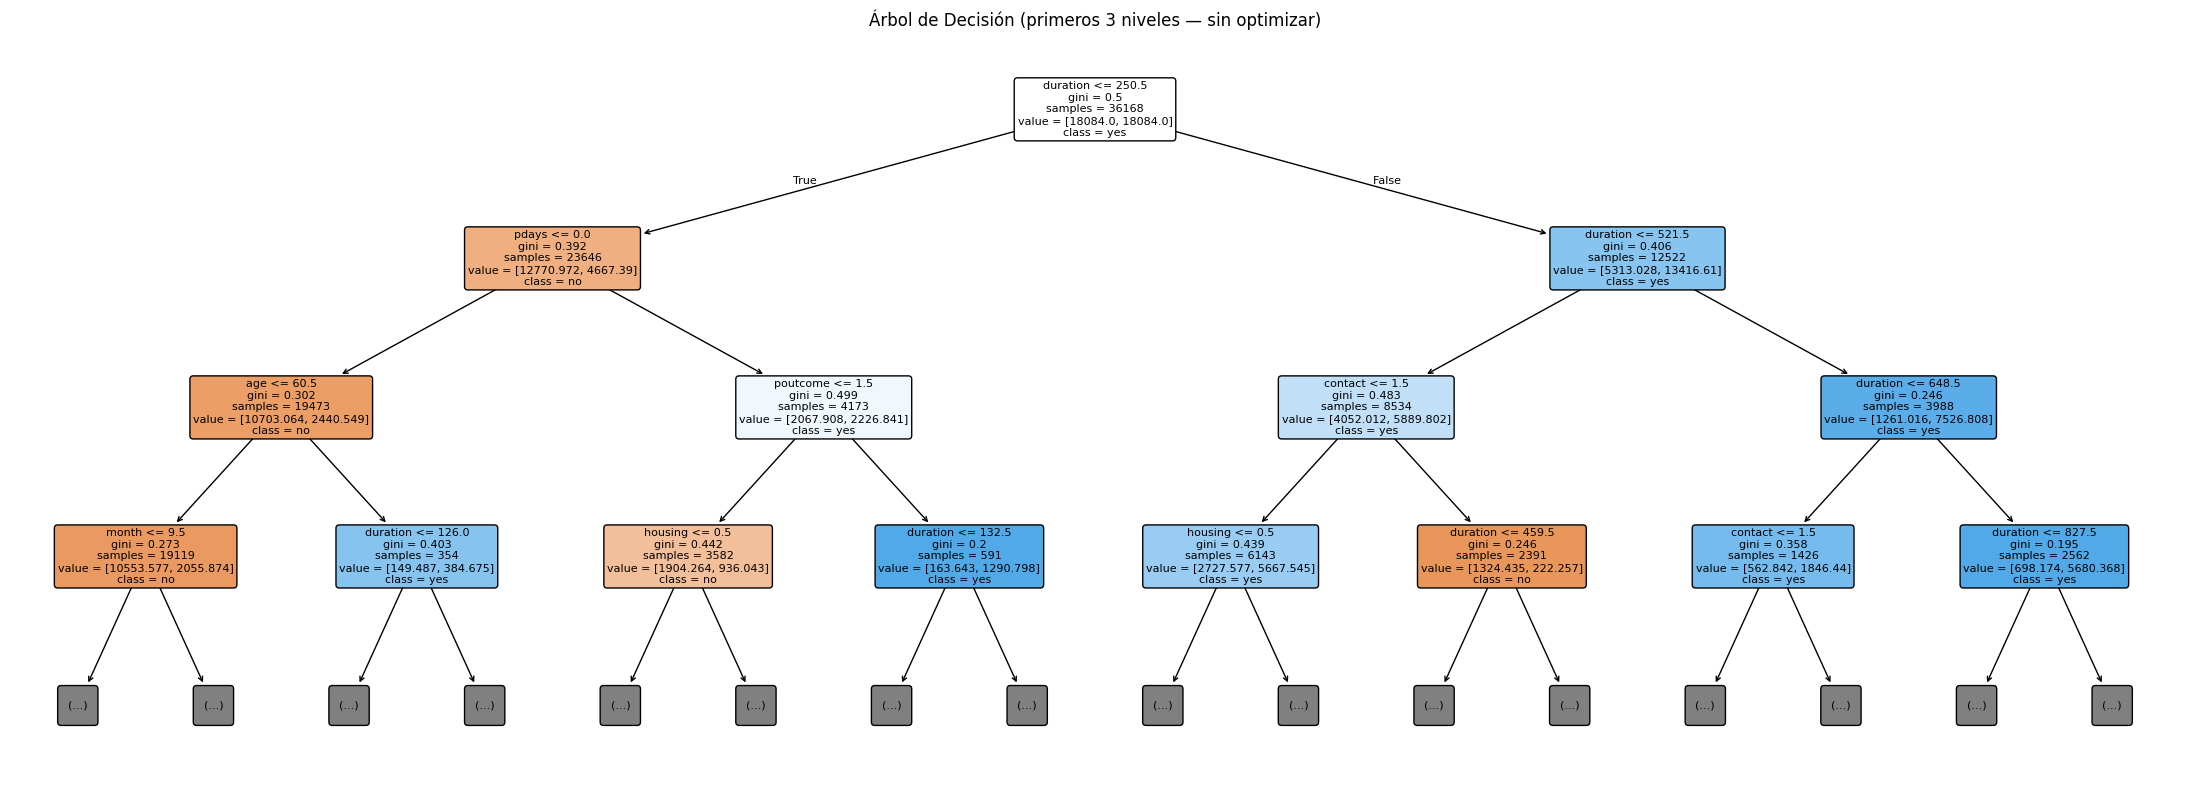

In [ ]:
# Visualizamos solo los primeros 3 niveles para que sea legible
plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Árbol de Decisión (primeros 3 niveles — sin optimizar)")
plt.tight_layout()
plt.show()

### Paso 8 — Optimización de hiperparámetros con GridSearchCV

Grid razonado:
- **`max_depth`**: controla el sobreajuste; de 3 (simple) a None (sin límite)
- **`min_samples_split`** y **`min_samples_leaf`**: regularización; valores altos reducen el sobreajuste
- **`criterion`**: gini vs entropy, pequeño impacto pero puede cambiar los cortes

Usamos **`scoring="roc_auc"`** porque es más informativa que accuracy con clases desbalanceadas.

In [ ]:
param_grid = {
    "max_depth":         [3, 5, 7, 10, None],
    "min_samples_split": [2, 20, 50],
    "min_samples_leaf":  [1, 10, 20],
    "criterion":         ["gini", "entropy"],
}

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_train, y_train)

print("\nMejores hiperparámetros:", gs.best_params_)
print(f"Mejor ROC-AUC (CV, 5 folds): {gs.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 50}
Mejor ROC-AUC (CV, 5 folds): 0.8930


### Paso 9 — Evaluación del árbol optimizado y comparación de modelos

=== ÁRBOL DE DECISIÓN (optimizado) ===
Profundidad del árbol: 10
              precision    recall  f1-score   support

          no       0.97      0.82      0.89      7985
         yes       0.38      0.82      0.52      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.82      0.71      9043
weighted avg       0.90      0.82      0.85      9043

ROC-AUC: 0.8903


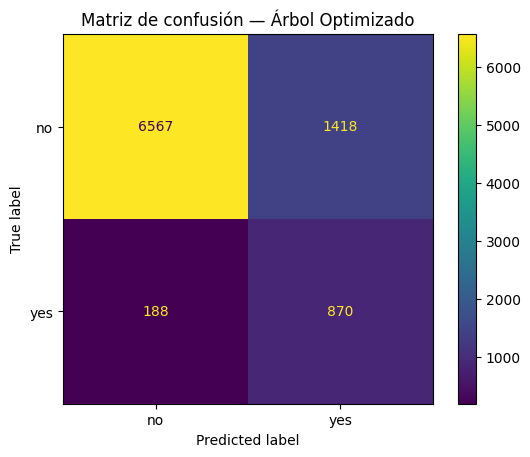

In [ ]:
best_dt = gs.best_estimator_

y_pred_best  = best_dt.predict(X_test)
y_proba_best = best_dt.predict_proba(X_test)[:, 1]
roc_best     = roc_auc_score(y_test, y_proba_best)

print("=== ÁRBOL DE DECISIÓN (optimizado) ===")
print(f"Profundidad del árbol: {best_dt.get_depth()}")
print(classification_report(y_test, y_pred_best, target_names=["no", "yes"]))
print(f"ROC-AUC: {roc_best:.4f}")

ConfusionMatrixDisplay.from_estimator(best_dt, X_test, y_test, display_labels=["no", "yes"])
plt.title("Matriz de confusión — Árbol Optimizado")
plt.show()

In [ ]:
# Tabla comparativa de los tres modelos
resumen = pd.DataFrame({
    "Modelo": ["Regresión Logística (baseline)", "Árbol (sin tuning)", "Árbol (optimizado)"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        roc_auc_score(y_test, y_proba_best),
    ],
    "F1 clase yes": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_best),
    ],
    "Precision yes": [
        classification_report(y_test, y_pred_lr,   output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_dt,   output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_best, output_dict=True)["1"]["precision"],
    ],
    "Recall yes": [
        classification_report(y_test, y_pred_lr,   output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_dt,   output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_best, output_dict=True)["1"]["recall"],
    ],
}).round(4)

resumen.set_index("Modelo")

,ROC-AUC,F1 clase yes,Precision yes,Recall yes
Modelo,,,,
Regresión Logística (baseline),0.8720,0.4866,0.3464,0.8176
Árbol (sin tuning),0.6801,0.4446,0.4667,0.4244
Árbol (optimizado),0.8903,0.5200,0.3802,0.8223


### Paso 10 — Importancia de features del modelo final

El árbol optimizado ya ha sido evaluado en test en el paso anterior.
Visualizamos qué features fueron más determinantes para sus decisiones.

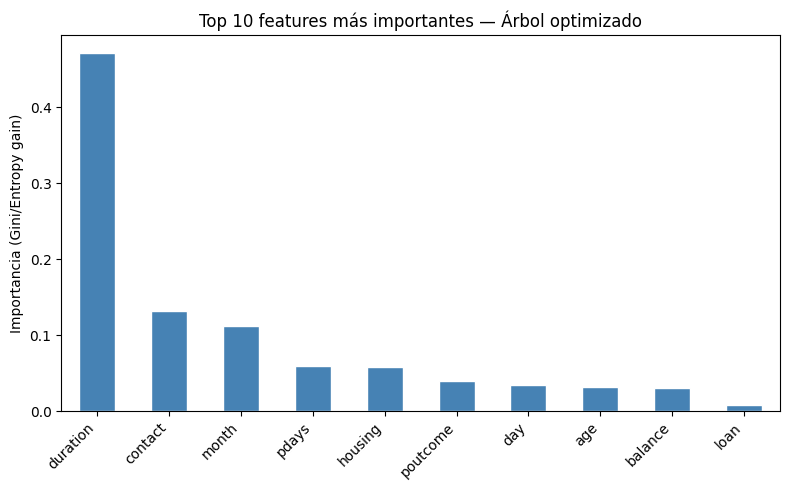

Feature más importante: duration


In [ ]:
feat_imp = (
    pd.Series(best_dt.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Top 10 features más importantes — Árbol optimizado")
plt.ylabel("Importancia (Gini/Entropy gain)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Feature más importante:", feat_imp.idxmax())

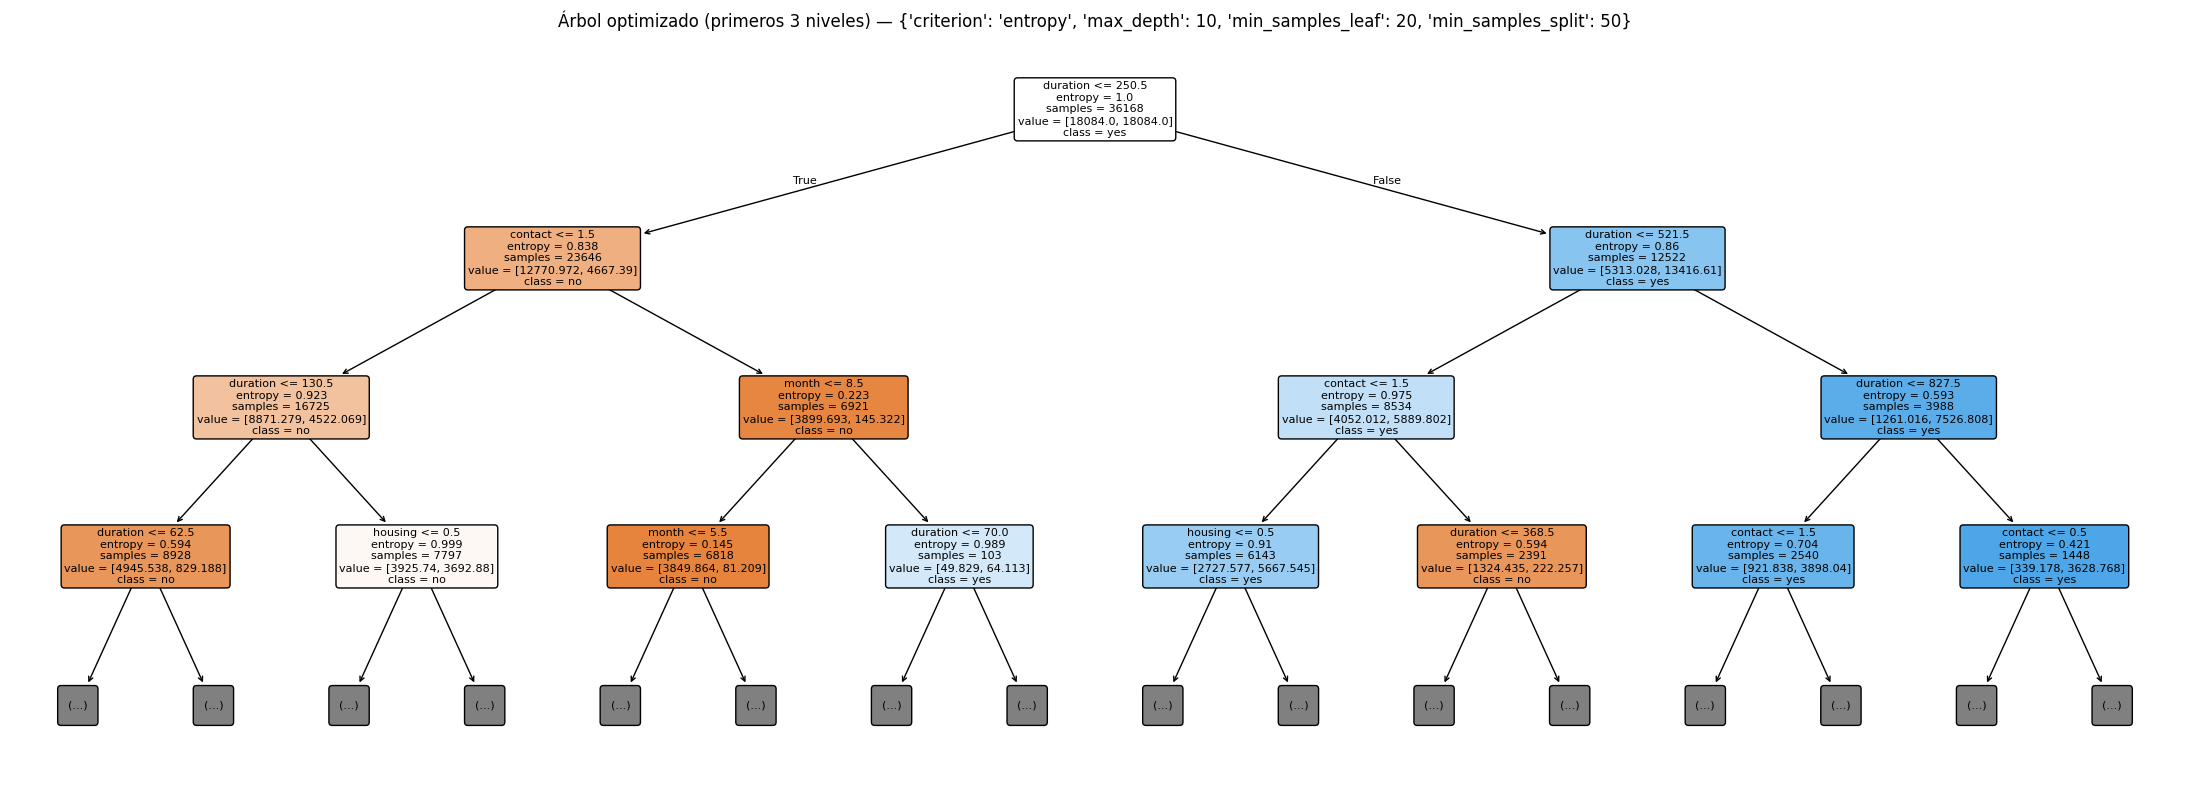

In [ ]:
# Visualización del árbol optimizado (primeros 3 niveles)
plt.figure(figsize=(22, 8))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=["no", "yes"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title(f"Árbol optimizado (primeros 3 niveles) — {gs.best_params_}")
plt.tight_layout()
plt.show()

### Conclusiones

- **Desbalanceo de clases**: con ~88% "no" / ~12% "yes", una accuracy alta es engañosa.
  Usar `class_weight="balanced"`, `stratify=y` y ROC-AUC como métrica principal es clave.

- **Árbol sin optimizar**: muy profundo → sobreajuste claro. Buen recall en train, peor en test.

- **GridSearchCV**: limitar `max_depth` y aumentar `min_samples_leaf` reduce el sobreajuste
  y mejora el ROC-AUC en test respecto al árbol sin ajustar.

- **Feature más importante**: `duration` (duración de la llamada) domina las decisiones del árbol.
  Atención: esta variable solo se conoce *después* de la llamada, dandole valor predictivo questionable.

- **Comparación con baseline**: el árbol optimizado es competitivo con la regresión logística
  en ROC-AUC y ofrece la ventaja de ser directamente interpretable a través de sus reglas.